In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo

sns.set_theme(style="whitegrid")
%matplotlib inline

In [54]:
heart = fetch_ucirepo(id=45)  # UCI Heart Disease dataset
X = heart.data.features
y = heart.data.targets

# Combine for EDA
df = X.copy()
df['target'] = y.values.ravel()

# Binarize: 0 = no disease, 1 = disease 
df['target'] = (df['target'] > 0).astype(int)

print(df.shape)
df.head()

(303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


In [55]:
df.info()

print("\nMissing values:\n", df.isnull().sum())
print("\nClass balance:\n", df['target'].value_counts())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(3), int64(11)
memory usage: 33.3 KB

Missing values:
 age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype

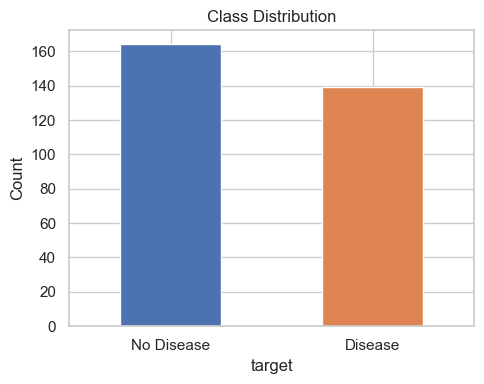

In [ ]:
# Target distribution
fig, ax = plt.subplots(figsize=(5, 4))
df['target'].value_counts().plot(kind='bar', ax=ax, color=['#4C72B0', '#DD8452'])
ax.set_xticklabels(['No Disease', 'Disease'], rotation=0)
ax.set_title('Class Distribution')
ax.set_ylabel('Count')
plt.tight_layout()
plt.savefig('../data/raw/class_distribution.png', dpi=150)
plt.show()

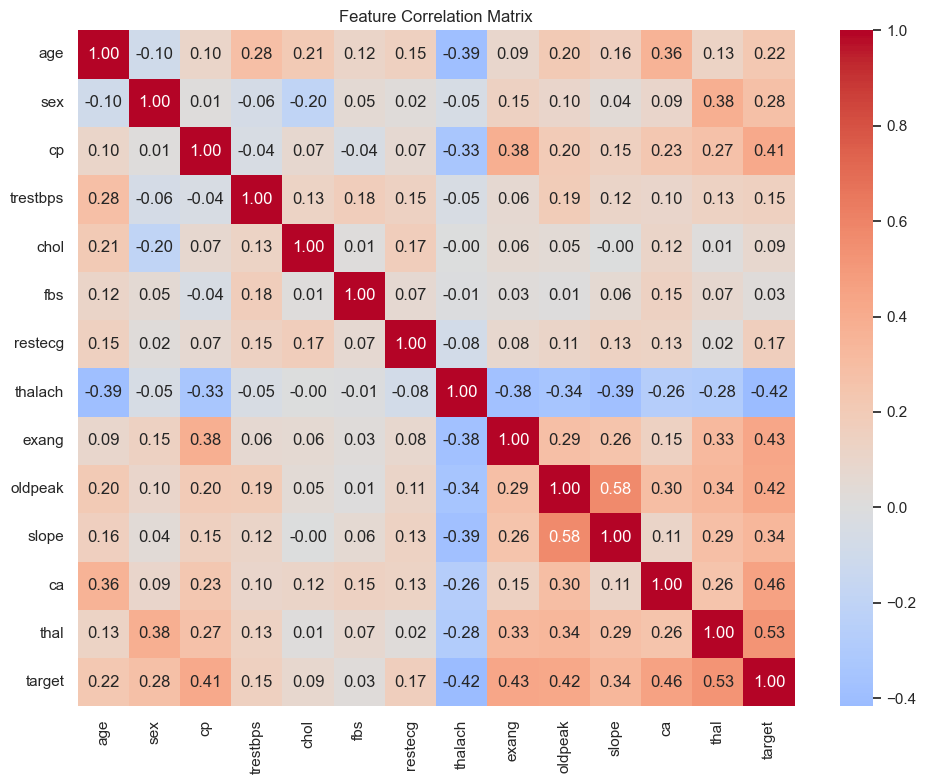

In [ ]:
# Correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.savefig('../data/raw/correlation_heatmap.png', dpi=150)
plt.show()

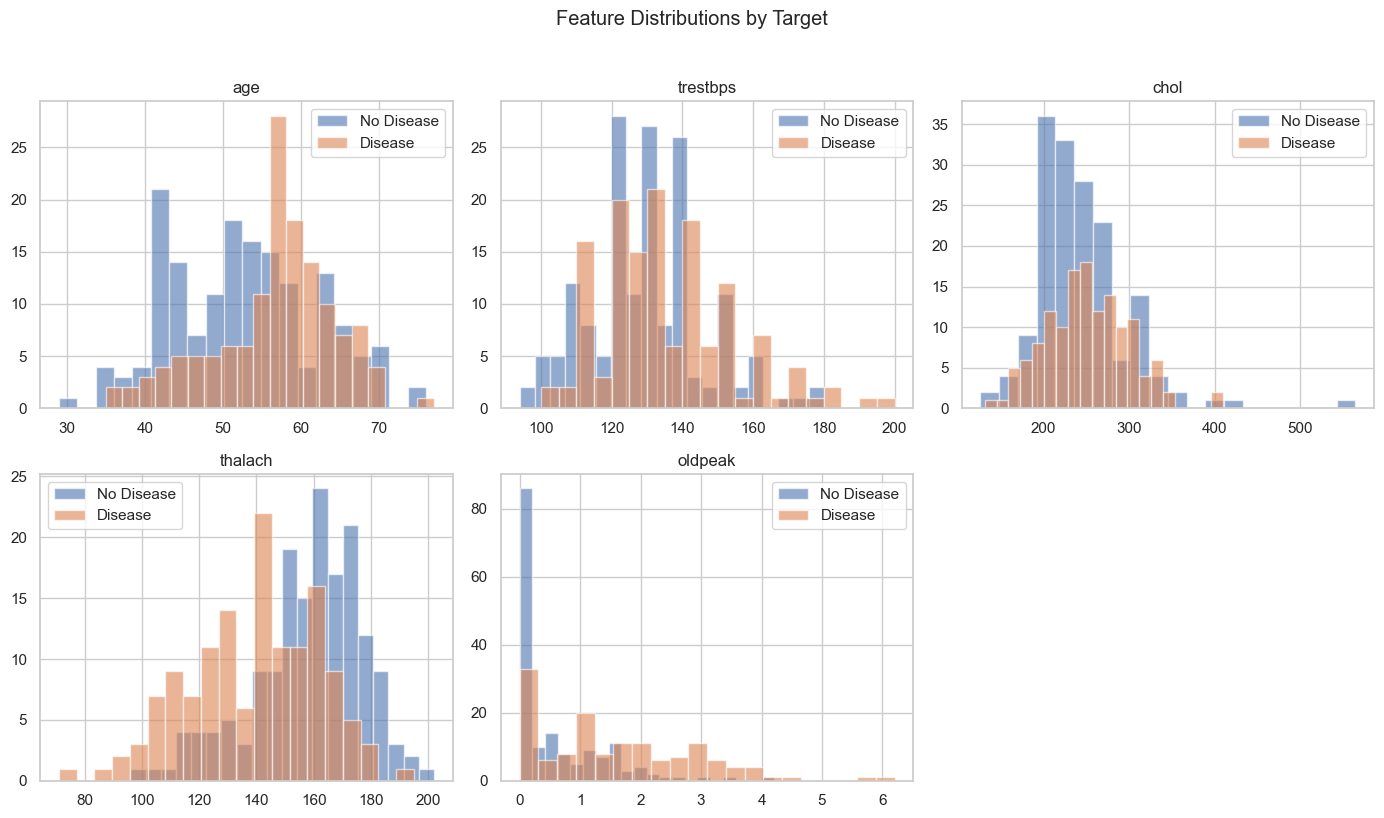

In [60]:
#Distribution of continuous features by target
continuous_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(continuous_cols):
    for label, color in zip([0, 1], ['#4C72B0', '#DD8452']):
        axes[i].hist(df[df['target'] == label][col], alpha=0.6,
            label=f'{"No Disease" if label==0 else "Disease"}',
            color=color, bins=20)
    axes[i].set_title(col)
    axes[i].legend()

fig.delaxes(axes[5])
plt.suptitle('Feature Distributions by Target', y=1.02)
plt.tight_layout()
plt.show()

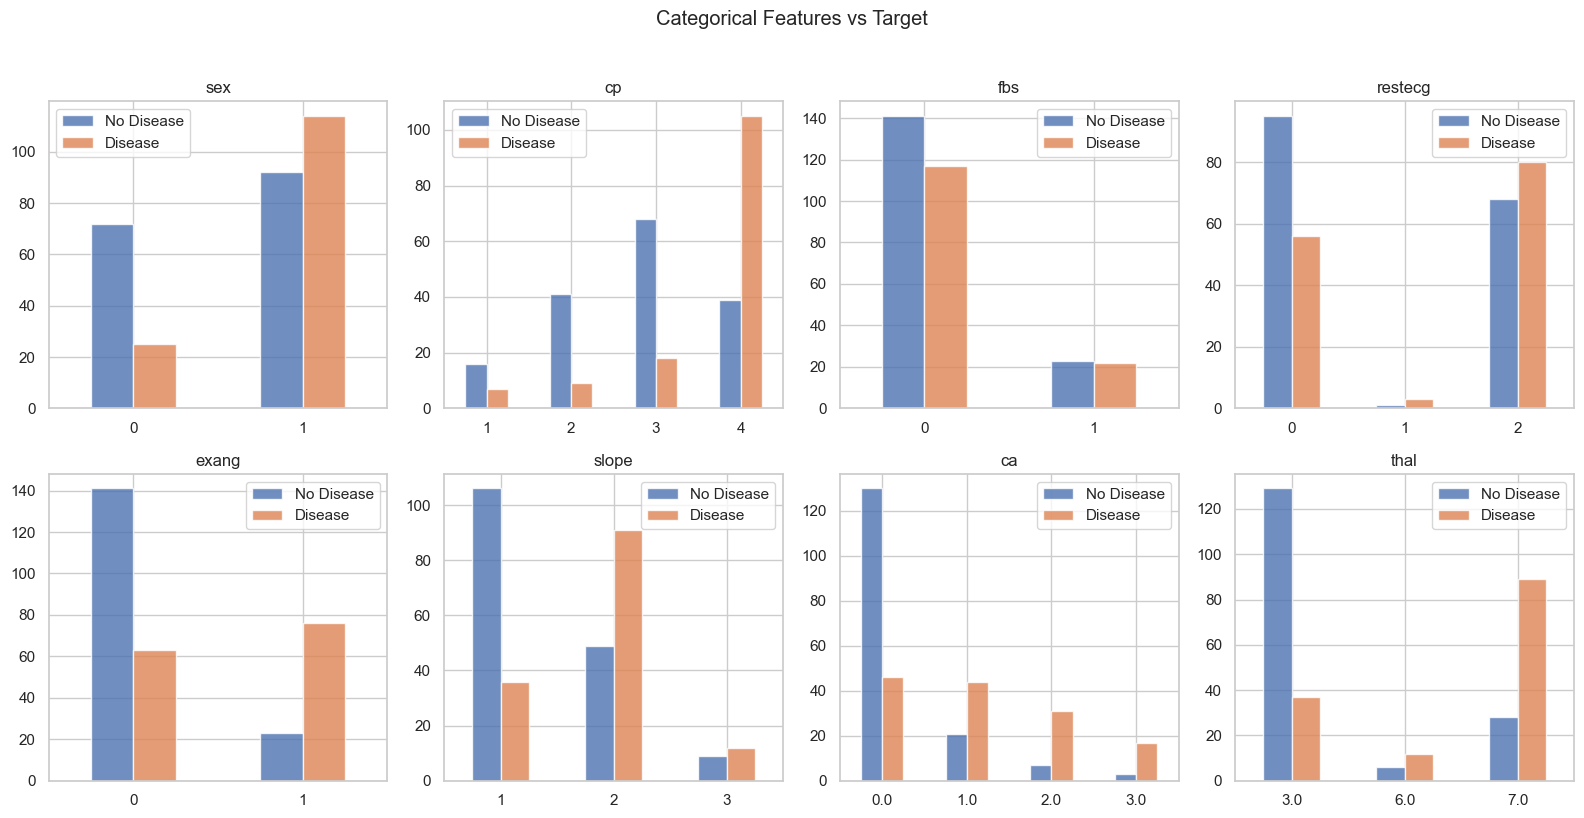

In [ ]:
# Categorical features vs target
categorical_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    ct = df.groupby([col, 'target']).size().unstack(fill_value=0)
    ct.plot(kind='bar', ax=axes[i], color=['#4C72B0', '#DD8452'], alpha=0.8)
    axes[i].set_title(col)
    axes[i].set_xlabel('')
    axes[i].legend(['No Disease', 'Disease'])
    axes[i].tick_params(axis='x', rotation=0)

plt.suptitle('Categorical Features vs Target', y=1.02)
plt.tight_layout()
plt.show()